In [1]:
# Basic Libraries
import os
import csv
import cv2
import time
import warnings
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier   # (cut off in image, likely this)

In [2]:
dataset_path = "BrainTumorDataset"

In [3]:
train_path = os.path.join(dataset_path,"Training")
test_path = os.path.join(dataset_path,"Testing")

classes = sorted(os.listdir(train_path))

print("Classes Found")
print(classes)

print("\n Number of Classes : ",len(classes))

Classes Found
['glioma', 'meningioma', 'notumor', 'pituitary']

 Number of Classes :  4


In [4]:
train_count = {}
test_count = {}

for cls in classes:
    train_count[cls] = len(os.listdir(os.path.join(train_path,cls)))
    test_count[cls] = len(os.listdir(os.path.join(test_path,cls)))

train_df = pd.DataFrame({
    "Training" : train_count,
    "Testing" : test_count
})

train_df

,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400


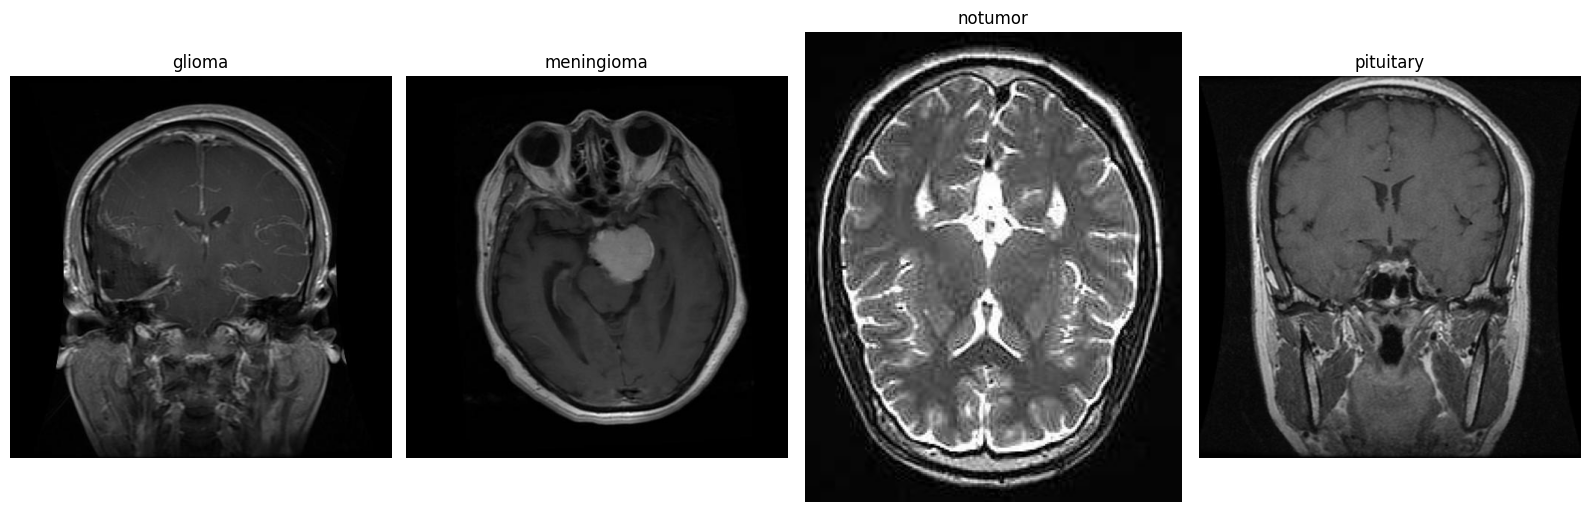

In [5]:
fig, axes = plt.subplots(1, len(classes), figsize=(16, 5))

for i, cls in enumerate(classes):
    image_path = os.path.join(
        train_path,
        cls,
        os.listdir(os.path.join(train_path, cls))[0]
    )
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
IMG_SIZE = 128

def preprocess_image(image_path):
    """
    Read image, resize, convert to grayscale
    """
    image = cv2.imread(image_path)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    return gray

In [7]:
def extract_hog(image):

    features = hog(
        image,
        orientations=9,      
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    return features

In [8]:
RADIUS = 2
N_POINTS = 8 * RADIUS

def extract_lbp(image):

    lbp = local_binary_pattern(
        image,
        N_POINTS,
        RADIUS,
        method = 'uniform'
    )

    hist,_ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0,N_POINTS + 3),
        range=(0,N_POINTS + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum()+ 1e-7)

    return hist

In [9]:
# GLCM Features
def extract_glcm(image):
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0,0]
    homogeneity = graycoprops(glcm, 'dissimilarity')[0,0]   
    energy = graycoprops(glcm, 'homogeneity')[0,0]          
    correlation = graycoprops(glcm, 'energy')[0,0]          
    asm = graycoprops(glcm, 'correlation')[0,0]             
    return np.array([
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation,
        asm
    ])

In [10]:
def extract_features(image_path):

    image=preprocess_image(image_path)

    hog_features = extract_hog(image)

    lbp_features = extract_lbp(image)

    glcm_features = extract_glcm(image)

    features = np.concatenate([
        hog_features,
        lbp_features,
        glcm_features
    ])

    return features

In [11]:
X = []
y = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    print(f"Loading {cls}...")
    
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        try:
            features = extract_features(image_path)
            X.append(features)
            y.append(cls)
        except Exception as e:
            print(f"Skipped {image_name}: {e}")
            continue

X = np.array(X)
y = np.array(y)

print(f"\nTotal samples loaded: {len(X)}")
print(f"Feature vector shape: {X.shape}")

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...

Total samples loaded: 5600
Feature vector shape: (5600, 8124)


In [12]:
X_test = []
y_test = []

for cls in classes:
    folder = os.path.join(test_path, cls)
    print(f"Loading {cls}...")
    
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        try:
            features = extract_features(image_path)
            X_test.append(features)
            y_test.append(cls)
        except Exception as e:
            print(f"Skipped {image_name}: {e}")
            continue

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"\nTotal test samples loaded: {len(X_test)}")
print(f"Feature vector shape: {X_test.shape}")

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...

Total test samples loaded: 1600
Feature vector shape: (1600, 8124)


In [13]:
# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training shape:", X.shape)
print("Testing shape:", X_test.shape)

Training shape: (5600, 8124)
Testing shape: (1600, 8124)


In [14]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)
y_test_encoded = le.transform(y_test)

print("Classes:", le.classes_)
print("Sample labels (before):", y[:5])
print("Sample labels (after):", y_encoded[:5])

Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']
Sample labels (before): ['glioma' 'glioma' 'glioma' 'glioma' 'glioma']
Sample labels (after): [0 0 0 0 0]


===== SVM Results =====
Accuracy: 0.9075
              precision    recall  f1-score   support

      glioma       0.98      0.70      0.82       400
  meningioma       0.85      0.95      0.89       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.90      1600
weighted avg       0.92      0.91      0.90      1600


===== Random Forest Results =====
Accuracy: 0.8481
              precision    recall  f1-score   support

      glioma       0.94      0.59      0.73       400
  meningioma       0.77      0.89      0.82       400
     notumor       0.82      1.00      0.90       400
   pituitary       0.91      0.92      0.91       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.84      1600
weighted avg       0.86      0.85      0.84      1600


Best model: SVM


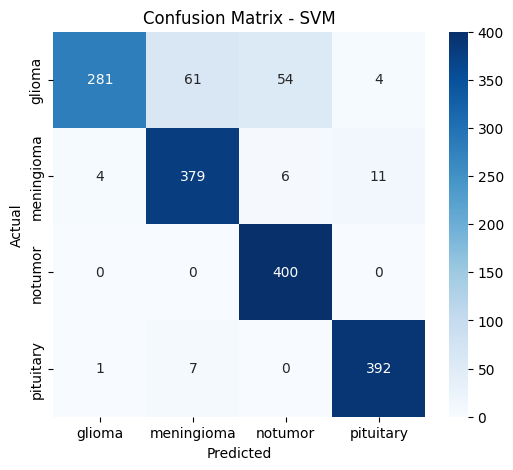


Model saved successfully!


In [15]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# ============================================
# Model 1: SVM
# ============================================
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_encoded)

svm_preds = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test_encoded, svm_preds)

print("===== SVM Results =====")
print(f"Accuracy: {svm_acc:.4f}")
print(classification_report(y_test_encoded, svm_preds, target_names=le.classes_))

# ============================================
# Model 2: Random Forest
# ============================================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X, y_encoded)   # RF ko scaling ki zarurat nahi

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test_encoded, rf_preds)

print("\n===== Random Forest Results =====")
print(f"Accuracy: {rf_acc:.4f}")
print(classification_report(y_test_encoded, rf_preds, target_names=le.classes_))


best_model_name = "SVM" if svm_acc > rf_acc else "Random Forest"
best_preds = svm_preds if svm_acc > rf_acc else rf_preds

print(f"\nBest model: {best_model_name}")

cm = confusion_matrix(y_test_encoded, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_model = svm_model if svm_acc > rf_acc else rf_model
joblib.dump(best_model, 'brain_tumor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("\nModel saved successfully!")

In [16]:
print(X.shape) 

(5600, 8124)
